# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/melikekaya01/flyrank-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [34]:
# Section 1 — Load Melike Kaya's repository and dataset safely.

from pathlib import Path
import os
import numpy as np
import pandas as pd

from IPython.display import display

REPO_URL = "https://github.com/melikekaya01/flyrank-ml.git"
REPO_DIR = Path("/content/flyrank-ml")

# Move to a safe directory before deleting or cloning the repository.
os.chdir("/content")

if REPO_DIR.exists():
    !rm -rf /content/flyrank-ml

!git clone {REPO_URL} {REPO_DIR}

if not REPO_DIR.exists():
    raise FileNotFoundError(
        "Repository clone failed."
    )

os.chdir(REPO_DIR)

candidate_paths = [
    Path("data/raw/content_refresh_anonymized.csv"),
    Path("/content/flyrank-ml/data/raw/content_refresh_anonymized.csv"),
]

DATA_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "The anonymized starter dataset could not be found."
    )

df = pd.read_csv(DATA_PATH)

required_columns = {
    "content_id",
    "client_id",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {sorted(missing_columns)}"
    )

print("Repository:", REPO_URL)
print("Dataset path:", DATA_PATH.resolve())
print(f"Rows loaded: {len(df):,}")
print(f"Columns loaded: {df.shape[1]}")

Cloning into '/content/flyrank-ml'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 149 (delta 57), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 1.92 MiB | 4.60 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Repository: https://github.com/melikekaya01/flyrank-ml.git
Dataset path: /content/flyrank-ml/data/raw/content_refresh_anonymized.csv
Rows loaded: 30,000
Columns loaded: 44


In [35]:
# Recreate Melike Kaya's validated Week-4 baseline exactly.

eligibility_mask = (
    (df["impressions_90d"] >= 500)
    & (df["avg_position"] <= 20)
    & (df["ctr"] < 0.5)
)

eligible_pages = df.loc[eligibility_mask].copy()

queue = eligible_pages.copy()

# 1. Visibility score: percentile rank of impression volume
queue["visibility_score"] = (
    queue["impressions_90d"]
    .rank(pct=True)
    .mul(100)
)

# 2. Position score: better positions receive higher scores
queue["position_score"] = (
    (20 - queue["avg_position"]) / 19 * 100
).clip(lower=0, upper=100)

# 3. Low-CTR score: CTR closer to zero receives higher priority
queue["low_ctr_score"] = (
    (0.5 - queue["ctr"]) / 0.5 * 100
).clip(lower=0, upper=100)

# 4. Low-engagement score:
# lower engagement receives higher priority within the eligible set
queue["low_engagement_score"] = (
    100
    - queue["engagement_rate"].rank(pct=True).mul(100)
)

# Weighted transparent action score
queue["action_score"] = (
    0.40 * queue["visibility_score"]
    + 0.30 * queue["position_score"]
    + 0.20 * queue["low_ctr_score"]
    + 0.10 * queue["low_engagement_score"]
)

queue = (
    queue
    .sort_values(
        by=[
            "action_score",
            "impressions_90d",
            "avg_position",
        ],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

queue.insert(0, "rank", range(1, len(queue) + 1))

print("Total dataset rows:", len(df))
print("Eligible review candidates:", len(queue))
print(
    "Eligible share:",
    f"{len(queue) / len(df):.2%}",
)

Total dataset rows: 30000
Eligible review candidates: 9759
Eligible share: 32.53%


In [36]:
# Add Week-7 playbook fields while preserving Melike's validated baseline.

ranked_queue = queue.copy()

ranked_queue["reason_code"] = "CTR_OPPORTUNITY_WITH_VISIBILITY"
ranked_queue["action_label"] = "REVIEW_TITLE_AND_META"

def assign_playbook_archetype(row):
    if (
        row["days_since_last_update"] >= 90
        and row["impressions_90d"] >= 500
    ):
        return "Older visible page with a CTR opportunity"

    if (
        row["avg_position"] <= 5
        and row["ctr"] < 0.20
    ):
        return "High-ranking page with weak search click-through"

    if row["engagement_rate"] < 20:
        return "Visible page with weak click-through and engagement"

    return "Visible page with a general CTR opportunity"


def assign_recommended_action(row):
    archetype = row["content_archetype"]

    if archetype == "Older visible page with a CTR opportunity":
        return (
            "Check factual freshness, then review title and meta description"
        )

    if archetype == "High-ranking page with weak search click-through":
        return (
            "Inspect SERP snippet, title clarity, and competing results"
        )

    if archetype == "Visible page with weak click-through and engagement":
        return (
            "Review title, meta description, intent match, and introduction"
        )

    return "Review title and meta description against search intent"


ranked_queue["content_archetype"] = ranked_queue.apply(
    assign_playbook_archetype,
    axis=1,
)

ranked_queue["recommended_action"] = ranked_queue.apply(
    assign_recommended_action,
    axis=1,
)

ranked_queue["review_priority"] = pd.cut(
    ranked_queue["rank"],
    bins=[0, 50, 200, 1000, np.inf],
    labels=[
        "P1 — Review first",
        "P2 — Review next",
        "P3 — Review when capacity allows",
        "P4 — Backlog",
    ],
)

display_columns = [
    "rank",
    "content_id",
    "client_id",
    "action_score",
    "review_priority",
    "reason_code",
    "action_label",
    "content_archetype",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

display(
    ranked_queue[display_columns]
    .head(20)
    .round(
        {
            "action_score": 2,
            "ctr": 4,
            "avg_position": 2,
            "engagement_rate": 2,
        }
    )
)

assert len(ranked_queue) == 9759
assert ranked_queue["action_score"].is_monotonic_decreasing

print("Validated queue rows:", len(ranked_queue))
print(
    "Reason code:",
    ranked_queue["reason_code"].unique().tolist(),
)
print(
    "Action label:",
    ranked_queue["action_label"].unique().tolist(),
)

,rank,content_id,client_id,action_score,review_priority,reason_code,action_label,content_archetype,recommended_action,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate,days_since_last_update
0,1,content_0022a6b4290f,client_f369cb89fc,91.21,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,High-ranking page with weak search click-through,"Inspect SERP snippet, title clarity, and compe...",29747,22,0.07,1.2,0.00,20
1,2,content_339b357d04c7,client_bbb965ab0c,91.01,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,High-ranking page with weak search click-through,"Inspect SERP snippet, title clarity, and compe...",46879,7,0.01,3.7,0.00,15
2,3,content_4a6607efcb46,client_6208ef0f77,90.67,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,Older visible page with a CTR opportunity,"Check factual freshness, then review title and...",128068,17,0.01,2.2,2.30,104
3,4,content_f4e210ee0c27,client_7f2253d7e2,90.32,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,High-ranking page with weak search click-through,"Inspect SERP snippet, title clarity, and compe...",24784,16,0.06,1.6,0.00,20
4,5,content_8451fc6f034d,client_d029fa3a95,90.07,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,High-ranking page with weak search click-through,"Inspect SERP snippet, title clarity, and compe...",272144,75,0.03,2.3,2.02,20
5,6,content_fea6a0d13b4a,client_19581e27de,89.86,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,Older visible page with a CTR opportunity,"Check factual freshness, then review title and...",79965,56,0.07,3.4,0.00,104
6,7,content_954cc45bd437,client_4e07408562,89.02,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,High-ranking page with weak search click-through,"Inspect SERP snippet, title clarity, and compe...",15439,6,0.04,1.5,0.00,7
7,8,content_f9d82e71e363,client_19581e27de,88.79,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,Older visible page with a CTR opportunity,"Check factual freshness, then review title and...",24260,19,0.08,2.0,0.00,104
8,9,content_dd635253d90e,client_6208ef0f77,88.26,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,Older visible page with a CTR opportunity,"Check factual freshness, then review title and...",33286,5,0.02,4.6,0.00,104
9,10,content_cbdf5a78dcd0,client_19581e27de,88.17,P1 — Review first,CTR_OPPORTUNITY_WITH_VISIBILITY,REVIEW_TITLE_AND_META,Older visible page with a CTR opportunity,"Check factual freshness, then review title and...",14830,3,0.02,2.4,0.00,104


Validated queue rows: 9759
Reason code: ['CTR_OPPORTUNITY_WITH_VISIBILITY']
Action label: ['REVIEW_TITLE_AND_META']


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [37]:
# Section 2 — Summarize archetypes, actions, and review capacity.

archetype_summary = (
    ranked_queue
    .groupby(
        [
            "content_archetype",
            "recommended_action",
        ],
        observed=True,
    )
    .agg(
        candidate_count=("content_id", "size"),
        median_action_score=("action_score", "median"),
        median_impressions=("impressions_90d", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median"),
        median_days_since_update=("days_since_last_update", "median"),
    )
    .reset_index()
    .sort_values(
        ["candidate_count", "median_action_score"],
        ascending=[False, False],
    )
)

archetype_summary["queue_share"] = (
    archetype_summary["candidate_count"] / len(ranked_queue)
)

display(
    archetype_summary.round(
        {
            "median_action_score": 2,
            "median_impressions": 0,
            "median_ctr": 4,
            "median_position": 2,
            "median_days_since_update": 0,
            "queue_share": 4,
        }
    )
)

,content_archetype,recommended_action,candidate_count,median_action_score,median_impressions,median_ctr,median_position,median_days_since_update,queue_share
3,Visible page with weak click-through and engag...,"Review title, meta description, intent match, ...",5662,53.23,3177.0,0.18,9.10,20.0,0.5802
1,Older visible page with a CTR opportunity,"Check factual freshness, then review title and...",3534,55.05,2947.0,0.16,7.70,104.0,0.3621
0,High-ranking page with weak search click-through,"Inspect SERP snippet, title clarity, and compe...",365,67.94,2912.0,0.09,3.70,20.0,0.0374
2,Visible page with a general CTR opportunity,Review title and meta description against sear...,198,41.03,1536.0,0.16,10.35,20.0,0.0203


In [38]:
# Review-capacity scenarios.

review_capacity = pd.DataFrame(
    {
        "review_scenario": [
            "Small weekly review",
            "Medium weekly review",
            "Expanded review cycle",
        ],
        "items_reviewed": [
            20,
            50,
            200,
        ],
        "estimated_minutes_per_item": [
            15,
            15,
            15,
        ],
    }
)

review_capacity["estimated_total_hours"] = (
    review_capacity["items_reviewed"]
    * review_capacity["estimated_minutes_per_item"]
    / 60
)

review_capacity["share_of_full_queue"] = (
    review_capacity["items_reviewed"] / len(ranked_queue)
)

display(
    review_capacity.round(
        {
            "estimated_total_hours": 1,
            "share_of_full_queue": 4,
        }
    )
)

,review_scenario,items_reviewed,estimated_minutes_per_item,estimated_total_hours,share_of_full_queue
0,Small weekly review,20,15,5.0,0.0020
1,Medium weekly review,50,15,12.5,0.0051
2,Expanded review cycle,200,15,50.0,0.0205


### Intended use

This playbook is intended to support a content analyst, SEO specialist, or editor who needs to decide which pages should be investigated first.

The validated Week-4 rule identifies pages with at least 500 impressions, an average search position of 20 or better, and a CTR below 0.5%. The resulting queue is ranked using visibility, position, low CTR, and low engagement.

The queue should be used as follows:

1. Select a review batch that matches available human-review capacity.
2. Read the content archetype and recommended action.
3. Inspect the actual page, search-result context, likely user intent, and business importance.
4. Decide whether to approve, reject, defer, investigate, or escalate the recommendation.
5. Record the human decision and measure any later outcome separately.

The queue is a decision-support tool. It is not an automatic editing system.

### Archetype-to-action mapping

The validated baseline keeps one transparent reason code:

- `CTR_OPPORTUNITY_WITH_VISIBILITY`

It also keeps one general action label:

- `REVIEW_TITLE_AND_META`

The Week-7 playbook adds more detailed archetypes without changing the validated eligibility rule or ranking score.

| Content archetype | Suggested human action |
|---|---|
| Older visible page with a CTR opportunity | Check factual freshness, then review the title and meta description |
| High-ranking page with weak search click-through | Inspect the SERP snippet, title clarity, and competing results |
| Visible page with weak click-through and engagement | Review the title, meta description, intent match, and introduction |
| Visible page with a general CTR opportunity | Review the title and meta description against search intent |

### Decay and refresh insight

Content age is used as a diagnostic signal, not as proof that a page needs to be refreshed.

Pages with at least 90 days since their last update and continued search visibility are grouped into an older-content archetype. This means the page may justify a factual freshness check.

It does not mean that the page is inaccurate, outdated, or guaranteed to improve after editing.

A human reviewer should check:

- whether facts, dates, examples, screenshots, or links are outdated;
- whether the page is evergreen or intentionally historical;
- whether the topic changes frequently;
- whether the page still satisfies the likely search intent;
- whether a refresh is worth the production cost.

### Operational limits

The full queue contains 9,759 records. Reviewing the entire queue at once would not be practical.

At an assumed 15 minutes per item:

- 20 records require approximately 5 hours;
- 50 records require approximately 12.5 hours;
- 200 records require approximately 50 hours.

The recommended starting point is a small pilot batch of 20 or 50 records.

The action score is a prioritization score. It is not:

- a probability of success;
- an expected traffic increase;
- a revenue estimate;
- a confidence score;
- a causal impact estimate.

The score does not include exact search queries, SERP features, conversion value, page ownership, legal risk, production cost, seasonality, brand requirements, or technical SEO problems.

### Evidence limits

In the earlier offline grouped evaluation, Melike Kaya's Week-4 baseline achieved a Precision@50 of 0.68.

Logistic Regression achieved 0.64, Random Forest achieved 0.58, and the held-out test-set positive base rate was 0.511.

These results show that the baseline concentrated positive labelled cases near the top of a small review queue. They do not prove that changing the recommended pages will cause more clicks, higher rankings, conversions, revenue, or business improvement.

There was no production deployment, randomized experiment, or causal impact evaluation.

### Non-production status

This notebook is a practical research prototype.

It does not provide:

- automatic content editing;
- automatic publishing;
- live workflow integration;
- authentication or access controls;
- production alerting;
- rollback controls;
- causal measurement;
- automatic retraining.

Its purpose is to generate a reproducible, human-reviewed recommendation queue for the research paper.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [39]:
# Section 3 — Human-review rules.

human_review_rules = pd.DataFrame(
    [
        {
            "review_step": 1,
            "rule": "Confirm page identity and ownership",
            "reviewer_check": (
                "Open the actual page and confirm that the record belongs "
                "to the expected client, site, and content type."
            ),
            "decision": (
                "Continue only when the page can be identified safely."
            ),
        },
        {
            "review_step": 2,
            "rule": "Inspect search intent and query context",
            "reviewer_check": (
                "Review available query context, search-result appearance, "
                "competing pages, and likely user need."
            ),
            "decision": (
                "Do not recommend title or content changes from aggregate CTR alone."
            ),
        },
        {
            "review_step": 3,
            "rule": "Check technical explanations first",
            "reviewer_check": (
                "Check indexation, canonical tags, redirects, page availability, "
                "tracking quality, and other technical causes."
            ),
            "decision": (
                "Do not rewrite content when a technical issue better explains the signal."
            ),
        },
        {
            "review_step": 4,
            "rule": "Assess factual and editorial risk",
            "reviewer_check": (
                "Check whether the page contains legal, medical, financial, "
                "regulated, contractual, or brand-sensitive claims."
            ),
            "decision": (
                "Escalate sensitive content to an authorized specialist."
            ),
        },
        {
            "review_step": 5,
            "rule": "Assess refresh necessity",
            "reviewer_check": (
                "For older visible content, verify whether facts, dates, examples, "
                "screenshots, links, or recommendations are genuinely outdated."
            ),
            "decision": (
                "Keep accurate evergreen or intentionally historical content unchanged."
            ),
        },
        {
            "review_step": 6,
            "rule": "Estimate effort and value",
            "reviewer_check": (
                "Compare likely review and editing effort with visibility, "
                "strategic importance, business value, and available capacity."
            ),
            "decision": (
                "Defer low-value or high-cost changes even when the score is high."
            ),
        },
        {
            "review_step": 7,
            "rule": "Record the human decision",
            "reviewer_check": (
                "Record approve, no-change, defer, investigate, or escalate "
                "together with a short rationale."
            ),
            "decision": (
                "No content action should occur without a documented reviewer decision."
            ),
        },
    ]
)

display(human_review_rules)

,review_step,rule,reviewer_check,decision
0,1,Confirm page identity and ownership,Open the actual page and confirm that the reco...,Continue only when the page can be identified ...
1,2,Inspect search intent and query context,"Review available query context, search-result ...",Do not recommend title or content changes from...
2,3,Check technical explanations first,"Check indexation, canonical tags, redirects, p...",Do not rewrite content when a technical issue ...
3,4,Assess factual and editorial risk,"Check whether the page contains legal, medical...",Escalate sensitive content to an authorized sp...
4,5,Assess refresh necessity,"For older visible content, verify whether fact...",Keep accurate evergreen or intentionally histo...
5,6,Estimate effort and value,Compare likely review and editing effort with ...,Defer low-value or high-cost changes even when...
6,7,Record the human decision,"Record approve, no-change, defer, investigate,...",No content action should occur without a docum...


In [40]:
# Define actions that must not be automated.

no_go_cases = pd.DataFrame(
    [
        {
            "no_go_case": "Automatic publishing or rewriting",
            "why_not": (
                "The score does not verify factual accuracy, search intent, "
                "brand voice, or editorial quality."
            ),
            "required_handling": (
                "Require human approval before any page change."
            ),
        },
        {
            "no_go_case": "Automatic title or meta replacement",
            "why_not": (
                "Low aggregate CTR may reflect query mix, SERP features, "
                "brand demand, seasonality, or measurement noise."
            ),
            "required_handling": (
                "Inspect search context and competing results first."
            ),
        },
        {
            "no_go_case": "Automatic deletion, deindexing, or redirects",
            "why_not": (
                "The queue does not measure backlinks, conversions, historical value, "
                "legal retention needs, or page dependencies."
            ),
            "required_handling": (
                "Require technical, editorial, and business-owner review."
            ),
        },
        {
            "no_go_case": "Automatic refresh based on age",
            "why_not": (
                "Older content may remain accurate, evergreen, intentionally historical, "
                "or useful without modification."
            ),
            "required_handling": (
                "Use age only as a trigger for a factual freshness check."
            ),
        },
        {
            "no_go_case": "Automatic action on sensitive content",
            "why_not": (
                "Medical, legal, financial, safety, regulated, or contractual material "
                "requires qualified review."
            ),
            "required_handling": (
                "Route to an authorized subject-matter expert."
            ),
        },
        {
            "no_go_case": "Automatic business-value claims",
            "why_not": (
                "The offline ranking does not estimate incremental traffic, revenue, "
                "conversions, rankings, or causal impact."
            ),
            "required_handling": (
                "Treat value estimates as hypotheses and measure outcomes separately."
            ),
        },
        {
            "no_go_case": "Cross-client comparison without context",
            "why_not": (
                "Clients may differ in audience, industry, traffic scale, "
                "strategy, and data quality."
            ),
            "required_handling": (
                "Review rankings within the relevant client context."
            ),
        },
    ]
)

display(no_go_cases)

,no_go_case,why_not,required_handling
0,Automatic publishing or rewriting,"The score does not verify factual accuracy, se...",Require human approval before any page change.
1,Automatic title or meta replacement,"Low aggregate CTR may reflect query mix, SERP ...",Inspect search context and competing results f...
2,"Automatic deletion, deindexing, or redirects","The queue does not measure backlinks, conversi...","Require technical, editorial, and business-own..."
3,Automatic refresh based on age,"Older content may remain accurate, evergreen, ...",Use age only as a trigger for a factual freshn...
4,Automatic action on sensitive content,"Medical, legal, financial, safety, regulated, ...",Route to an authorized subject-matter expert.
5,Automatic business-value claims,The offline ranking does not estimate incremen...,Treat value estimates as hypotheses and measur...
6,Cross-client comparison without context,"Clients may differ in audience, industry, traf...",Review rankings within the relevant client con...


### Human-review policy

Every row in the ranked queue is a recommendation to investigate, not an instruction to edit.

Before approving an action, a reviewer must inspect the actual page and its context. The reviewer should verify page identity, search intent, factual accuracy, technical SEO conditions, business importance, editing effort, and any legal or brand constraints.

The minimum decision set is:

- `APPROVE_ACTION`: the proposed action is justified;
- `NO_CHANGE`: the page should remain unchanged;
- `DEFER`: the opportunity may be valid but is not currently worth the cost;
- `INVESTIGATE`: more query, analytics, technical, or business context is needed;
- `ESCALATE`: the page requires an authorized owner or specialist.

A high action score must not override evidence found during manual review.

### What must not be automated

The notebook must not directly rewrite, publish, delete, redirect, deindex, or otherwise modify content.

It must not automatically replace titles or meta descriptions. Aggregate CTR and average position do not reveal the exact query mix, SERP layout, user intent, brand context, or competing-result quality.

It must not automatically refresh content because it is older. The 90-day threshold is a diagnostic signal for a freshness check, not proof that the page is outdated.

It must not make unsupervised changes to legal, medical, financial, safety-related, contractual, regulated, or brand-sensitive content.

It must not claim expected traffic, ranking, conversion, revenue, or business gains. The current evidence is based on offline ranking evaluation and does not estimate causal impact.

### Cost and value thinking

Review capacity is limited, so the action score should be combined with human estimates of cost and value.

Reviewers should consider:

- analyst and editor time;
- need for design, development, legal, or specialist support;
- search visibility;
- strategic importance;
- likely user and business value;
- reversibility of the change;
- availability of a reliable measurement period.

A low-cost metadata investigation may be prioritized before a full rewrite. A technically complex or sensitive change may be deferred even when its score is high.

The preferred starting point is a pilot batch of 20 or 50 records.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [41]:
# Section 4 — Lightweight monitoring and retraining triggers.

monitoring_plan = pd.DataFrame(
    [
        {
            "monitor": "Queue size",
            "metric": "Number of eligible review candidates",
            "current_reference": len(ranked_queue),
            "check_frequency": "Each notebook run",
            "trigger": (
                "Investigate if the queue changes by more than 30% "
                "without an expected data or rule change."
            ),
            "response": (
                "Check data completeness, source definitions, thresholds, "
                "and upstream reporting changes."
            ),
        },
        {
            "monitor": "Archetype distribution",
            "metric": "Share of candidates assigned to each content archetype",
            "current_reference": "See archetype_summary table",
            "check_frequency": "Each notebook run",
            "trigger": (
                "Investigate if one archetype changes by more than "
                "15 percentage points from the previous run."
            ),
            "response": (
                "Check whether source distributions, content mix, "
                "or archetype thresholds changed."
            ),
        },
        {
            "monitor": "Score distribution",
            "metric": "Median and upper-percentile action score",
            "current_reference": round(
                ranked_queue["action_score"].median(),
                2,
            ),
            "check_frequency": "Each notebook run",
            "trigger": (
                "Investigate if the median score moves by more than 10 points "
                "or the top-score range changes unexpectedly."
            ),
            "response": (
                "Compare impressions, CTR, position, and engagement "
                "with the prior reference period."
            ),
        },
        {
            "monitor": "Input quality",
            "metric": "Missing or invalid values in required columns",
            "current_reference": "Calculated below",
            "check_frequency": "Each notebook run",
            "trigger": (
                "Stop queue generation if required fields are missing, "
                "mostly null, or outside plausible ranges."
            ),
            "response": (
                "Fix or document the data-quality issue before using the queue."
            ),
        },
        {
            "monitor": "Top-queue usefulness",
            "metric": "Human-confirmed useful cases among the first 50 reviews",
            "current_reference": "Offline Precision@50 reference: 0.68",
            "check_frequency": "After each completed 50-item review batch",
            "trigger": (
                "Review the rule if confirmed usefulness falls below 0.60 "
                "for two consecutive batches."
            ),
            "response": (
                "Inspect rejected cases, revise archetypes or thresholds, "
                "and validate again before wider use."
            ),
        },
        {
            "monitor": "Reviewer rejection rate",
            "metric": "Share marked NO_CHANGE or rejected",
            "current_reference": "Not yet collected",
            "check_frequency": "After each review batch",
            "trigger": (
                "Investigate if more than 50% of reviewed items are rejected "
                "for the same recurring reason."
            ),
            "response": (
                "Convert reviewer feedback into an exclusion rule "
                "or revised action mapping."
            ),
        },
        {
            "monitor": "Data freshness",
            "metric": "Age of the latest source reporting period",
            "current_reference": "Depends on source refresh",
            "check_frequency": "Before each use",
            "trigger": (
                "Do not use the queue if the source period is stale "
                "for the intended review decision."
            ),
            "response": (
                "Refresh the source data and regenerate notebook outputs."
            ),
        },
    ]
)

display(monitoring_plan)


,monitor,metric,current_reference,check_frequency,trigger,response
0,Queue size,Number of eligible review candidates,9759,Each notebook run,Investigate if the queue changes by more than ...,"Check data completeness, source definitions, t..."
1,Archetype distribution,Share of candidates assigned to each content a...,See archetype_summary table,Each notebook run,Investigate if one archetype changes by more t...,"Check whether source distributions, content mi..."
2,Score distribution,Median and upper-percentile action score,54.12,Each notebook run,Investigate if the median score moves by more ...,"Compare impressions, CTR, position, and engage..."
3,Input quality,Missing or invalid values in required columns,Calculated below,Each notebook run,Stop queue generation if required fields are m...,Fix or document the data-quality issue before ...
4,Top-queue usefulness,Human-confirmed useful cases among the first 5...,Offline Precision@50 reference: 0.68,After each completed 50-item review batch,Review the rule if confirmed usefulness falls ...,"Inspect rejected cases, revise archetypes or t..."
5,Reviewer rejection rate,Share marked NO_CHANGE or rejected,Not yet collected,After each review batch,Investigate if more than 50% of reviewed items...,Convert reviewer feedback into an exclusion ru...
6,Data freshness,Age of the latest source reporting period,Depends on source refresh,Before each use,Do not use the queue if the source period is s...,Refresh the source data and regenerate noteboo...


In [42]:
# Basic input-quality monitoring checks.

required_monitoring_columns = [
    "content_id",
    "client_id",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
]

data_quality_summary = pd.DataFrame(
    {
        "column": required_monitoring_columns,
        "missing_count": [
            df[column].isna().sum()
            for column in required_monitoring_columns
        ],
        "missing_share": [
            df[column].isna().mean()
            for column in required_monitoring_columns
        ],
        "unique_values": [
            df[column].nunique(dropna=True)
            for column in required_monitoring_columns
        ],
    }
)

display(
    data_quality_summary.round(
        {
            "missing_share": 4,
        }
    )
)

,column,missing_count,missing_share,unique_values
0,content_id,0,0.0,30000
1,client_id,0,0.0,32
2,impressions_90d,0,0.0,9438
3,clicks_90d,0,0.0,477
4,ctr,0,0.0,401
5,avg_position,0,0.0,869
6,engagement_rate,0,0.0,915
7,days_since_last_update,0,0.0,57


In [43]:
# Create a compact monitoring snapshot for future comparison.

monitoring_snapshot = {
    "source_rows": int(len(df)),
    "eligible_queue_rows": int(len(ranked_queue)),
    "eligible_queue_share": float(
        len(ranked_queue) / len(df)
    ),
    "median_action_score": float(
        ranked_queue["action_score"].median()
    ),
    "p90_action_score": float(
        ranked_queue["action_score"].quantile(0.90)
    ),
    "top_50_minimum_score": float(
        ranked_queue.head(50)["action_score"].min()
    ),
    "archetype_counts": {
        str(key): int(value)
        for key, value in ranked_queue[
            "content_archetype"
        ].value_counts().to_dict().items()
    },
    "reason_code": "CTR_OPPORTUNITY_WITH_VISIBILITY",
    "action_label": "REVIEW_TITLE_AND_META",
}

monitoring_snapshot

{'source_rows': 30000,
 'eligible_queue_rows': 9759,
 'eligible_queue_share': 0.3253,
 'median_action_score': 54.116562848868256,
 'p90_action_score': 73.42852233565777,
 'top_50_minimum_score': 84.44153035524563,
 'archetype_counts': {'Visible page with weak click-through and engagement': 5662,
  'Older visible page with a CTR opportunity': 3534,
  'High-ranking page with weak search click-through': 365,
  'Visible page with a general CTR opportunity': 198},
 'reason_code': 'CTR_OPPORTUNITY_WITH_VISIBILITY',
 'action_label': 'REVIEW_TITLE_AND_META'}

### Monitoring approach

This notebook uses lightweight monitoring rather than production-grade model monitoring.

The main checks focus on whether the queue is still generated from comparable data and whether human reviewers continue to find the top-ranked records useful.

The following signals should be checked whenever the notebook is rerun:

- total source-row count;
- eligible queue size and eligible share;
- missing values in required fields;
- median and upper-percentile action scores;
- distribution of content archetypes;
- reviewer decisions from completed review batches;
- age and completeness of the source reporting period.

A large change does not automatically mean that the playbook has failed. It is a signal to investigate whether the data source, client mix, content portfolio, reporting definitions, or review assumptions have changed.

### Retraining and rule-review triggers

The selected method is a transparent fixed-rule baseline rather than a continuously trained production model.

For this project, retraining means repeating the model comparison and grouped validation process. It does not mean automatically updating a live model.

A new validation and model-comparison cycle should be considered when:

- the source schema or metric definitions change;
- new clients or substantially different content types are introduced;
- the queue changes by more than 30% without a known cause;
- one archetype changes by more than 15 percentage points;
- the action-score distribution changes materially;
- human-confirmed usefulness in the top 50 falls below 0.60 for two consecutive batches;
- reviewers repeatedly reject recommendations for the same missing contextual factor;
- enough new labelled outcomes are available;
- the operational objective or review capacity changes.

Any revised rule or replacement model should be compared with the current baseline using grouped validation and the same operational metric.

A more complex model should not be selected only because it has a higher ROC-AUC.

### Monitoring limits

These checks do not detect every possible form of drift or data-quality failure.

Human-review decisions may also be subjective. Reviewer guidelines should remain consistent, and disagreements should be documented.

The monitoring snapshot is a reproducibility receipt for future notebook runs. It is not a production alerting service and does not trigger automatic content changes or automatic retraining.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [44]:
# Section 5 — Export Melike Kaya's ranked queue and paper receipts.

from pathlib import Path
import json
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

queue_export_columns = [
    "rank",
    "content_id",
    "client_id",
    "action_score",
    "review_priority",
    "reason_code",
    "action_label",
    "content_archetype",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
    "visibility_score",
    "position_score",
    "low_ctr_score",
    "low_engagement_score",
]

queue_export = ranked_queue[queue_export_columns].copy()

QUEUE_PATH = OUTPUT_DIR / "w07_ranked_action_queue.csv"

queue_export.to_csv(
    QUEUE_PATH,
    index=False,
)

print("Queue export created:", QUEUE_PATH)
print(f"Exported rows: {len(queue_export):,}")


Queue export created: work/outputs/w07_ranked_action_queue.csv
Exported rows: 9,759


In [45]:
# Export the main metrics receipt used by the paper.

archetype_counts = {
    str(archetype): int(count)
    for archetype, count in ranked_queue[
        "content_archetype"
    ].value_counts().items()
}

archetype_shares = {
    str(archetype): float(share)
    for archetype, share in ranked_queue[
        "content_archetype"
    ].value_counts(normalize=True).items()
}

playbook_metrics = {
    "project_owner": "Melike Kaya",
    "source_rows": int(len(df)),
    "eligible_queue_rows": int(len(ranked_queue)),
    "eligible_queue_share": float(
        len(ranked_queue) / len(df)
    ),
    "eligibility_rule": {
        "minimum_impressions_90d": 500,
        "maximum_avg_position": 20,
        "maximum_ctr_percent": 0.5,
    },
    "median_action_score": float(
        ranked_queue["action_score"].median()
    ),
    "p90_action_score": float(
        ranked_queue["action_score"].quantile(0.90)
    ),
    "top_20_minimum_score": float(
        ranked_queue.head(20)["action_score"].min()
    ),
    "top_50_minimum_score": float(
        ranked_queue.head(50)["action_score"].min()
    ),
    "reason_code": "CTR_OPPORTUNITY_WITH_VISIBILITY",
    "action_label": "REVIEW_TITLE_AND_META",
    "archetype_counts": archetype_counts,
    "archetype_shares": archetype_shares,
    "review_capacity_assumption_minutes_per_item": 15,
    "offline_precision_at_50_reference": 0.68,
    "logistic_regression_precision_at_50_reference": 0.64,
    "random_forest_precision_at_50_reference": 0.58,
    "test_base_rate_reference": 0.511,
    "selected_method": "Week-4 fixed-rule baseline",
    "intended_use": (
        "Human-reviewed prioritization queue for content investigation"
    ),
    "automation_status": (
        "No automatic editing, publishing, deletion, redirecting, "
        "deindexing, or retraining"
    ),
}

METRICS_PATH = (
    OUTPUT_DIR / "w07_action_playbook_metrics.json"
)

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(
        playbook_metrics,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Metrics receipt created:", METRICS_PATH)

Metrics receipt created: work/outputs/w07_action_playbook_metrics.json


In [46]:
# Export the monitoring receipt.

MONITORING_PATH = (
    OUTPUT_DIR / "w07_monitoring_snapshot.json"
)

with open(MONITORING_PATH, "w", encoding="utf-8") as file:
    json.dump(
        monitoring_snapshot,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Monitoring receipt created:", MONITORING_PATH)

Monitoring receipt created: work/outputs/w07_monitoring_snapshot.json


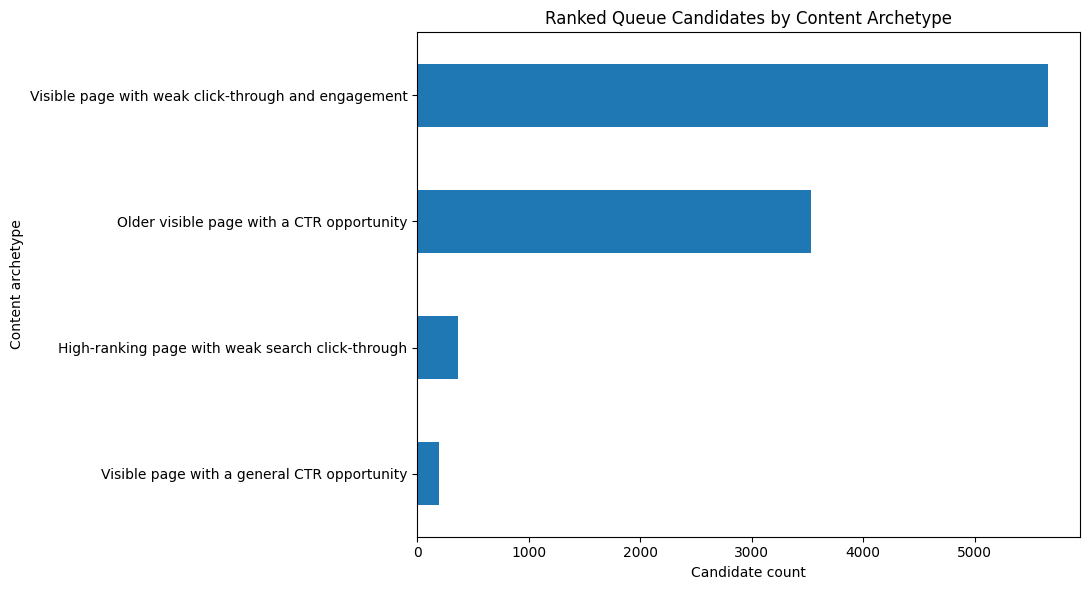

Figure created: work/figures/w07_archetype_candidate_counts.png


In [47]:
# Figure 1 — Candidate count by content archetype.

archetype_count_figure = (
    ranked_queue["content_archetype"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(11, 6))
archetype_count_figure.plot(kind="barh")

plt.title("Ranked Queue Candidates by Content Archetype")
plt.xlabel("Candidate count")
plt.ylabel("Content archetype")
plt.tight_layout()

ARCHETYPE_FIGURE_PATH = (
    FIGURE_DIR / "w07_archetype_candidate_counts.png"
)

plt.savefig(
    ARCHETYPE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figure created:", ARCHETYPE_FIGURE_PATH)

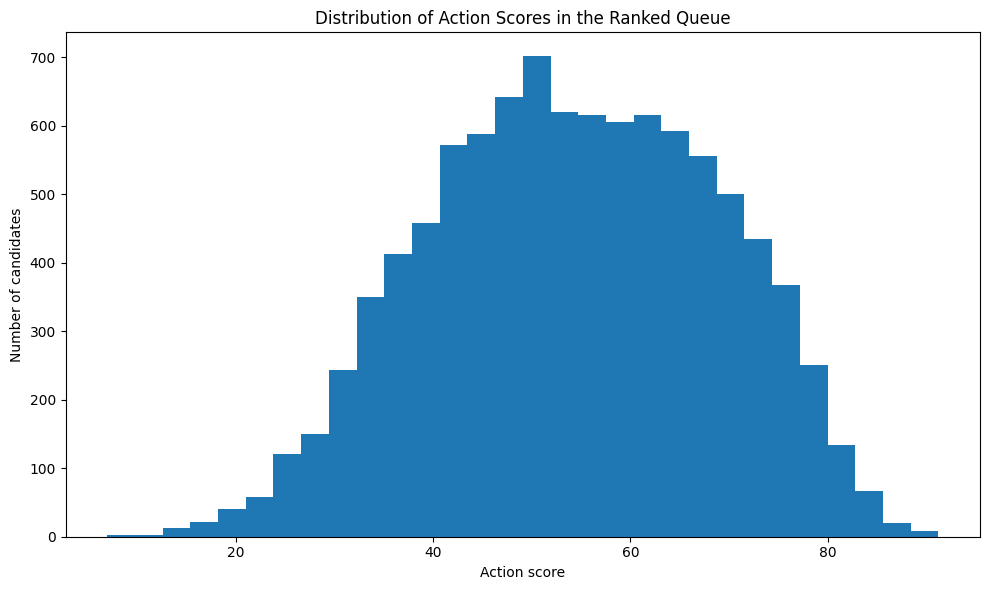

Figure created: work/figures/w07_action_score_distribution.png


In [48]:
# Figure 2 — Distribution of action scores.

plt.figure(figsize=(10, 6))
plt.hist(
    ranked_queue["action_score"],
    bins=30,
)

plt.title("Distribution of Action Scores in the Ranked Queue")
plt.xlabel("Action score")
plt.ylabel("Number of candidates")
plt.tight_layout()

SCORE_FIGURE_PATH = (
    FIGURE_DIR / "w07_action_score_distribution.png"
)

plt.savefig(
    SCORE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Figure created:", SCORE_FIGURE_PATH)

In [49]:
# Confirm that every expected export exists.

expected_exports = [
    QUEUE_PATH,
    METRICS_PATH,
    MONITORING_PATH,
    ARCHETYPE_FIGURE_PATH,
    SCORE_FIGURE_PATH,
]

export_check = pd.DataFrame(
    {
        "file": [
            str(path)
            for path in expected_exports
        ],
        "exists": [
            path.exists()
            for path in expected_exports
        ],
        "size_bytes": [
            path.stat().st_size if path.exists() else 0
            for path in expected_exports
        ],
        "commit_to_git": [
            False,
            True,
            True,
            True,
            True,
        ],
    }
)

display(export_check)

if not export_check["exists"].all():
    raise FileNotFoundError(
        "One or more expected exports were not created."
    )

,file,exists,size_bytes,commit_to_git
0,work/outputs/w07_ranked_action_queue.csv,True,3243976,False
1,work/outputs/w07_action_playbook_metrics.json,True,1601,True
2,work/outputs/w07_monitoring_snapshot.json,True,582,True
3,work/figures/w07_archetype_candidate_counts.png,True,95333,True
4,work/figures/w07_action_score_distribution.png,True,56580,True


### Export policy

The notebook generates the following paper-ready outputs:

| File | Purpose | Git policy |
|---|---|---|
| `work/outputs/w07_ranked_action_queue.csv` | Full ranked human-review queue | Regenerated locally and kept out of Git |
| `work/outputs/w07_action_playbook_metrics.json` | Queue, score, archetype, and evaluation receipts | Commit |
| `work/outputs/w07_monitoring_snapshot.json` | Lightweight reference for future notebook runs | Commit |
| `work/figures/w07_archetype_candidate_counts.png` | Paper-ready archetype distribution figure | Commit |
| `work/figures/w07_action_score_distribution.png` | Paper-ready action-score distribution figure | Commit |

The queue CSV contains anonymized content and client identifiers. It is an analysis output rather than a production task list, and it does not authorize content changes.

The JSON files act as reproducibility receipts. They preserve the main counts, thresholds, reference metrics, assumptions, and monitoring values used by the notebook.

The figures are descriptive. They show the composition and score distribution of the ranked queue. They do not show causal impact, expected traffic gains, revenue uplift, conversion improvement, or ranking improvement.

The queue CSV remains outside Git because the repository leak guard blocks data files by design. The notebook regenerates it whenever it runs.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [50]:
# Section 6 — Final reproducibility and export checks.

from pathlib import Path

NOTEBOOK_PATH = Path(
    "work/notebooks/w07_action_playbook.ipynb"
)

required_files = {
    "Notebook": NOTEBOOK_PATH,
    "Metrics JSON": Path(
        "work/outputs/w07_action_playbook_metrics.json"
    ),
    "Monitoring JSON": Path(
        "work/outputs/w07_monitoring_snapshot.json"
    ),
    "Archetype figure": Path(
        "work/figures/w07_archetype_candidate_counts.png"
    ),
    "Score-distribution figure": Path(
        "work/figures/w07_action_score_distribution.png"
    ),
}

self_check_results = pd.DataFrame(
    {
        "check": [
            f"{name} exists"
            for name in required_files
        ],
        "passed": [
            path.exists()
            for path in required_files.values()
        ],
        "path": [
            str(path)
            for path in required_files.values()
        ],
    }
)

display(self_check_results)

if not self_check_results["passed"].all():
    missing = self_check_results.loc[
        ~self_check_results["passed"],
        "path",
    ].tolist()

    raise FileNotFoundError(
        f"Missing required files: {missing}"
    )

print("All required notebook, JSON, and figure files exist.")

,check,passed,path
0,Notebook exists,True,work/notebooks/w07_action_playbook.ipynb
1,Metrics JSON exists,True,work/outputs/w07_action_playbook_metrics.json
2,Monitoring JSON exists,True,work/outputs/w07_monitoring_snapshot.json
3,Archetype figure exists,True,work/figures/w07_archetype_candidate_counts.png
4,Score-distribution figure exists,True,work/figures/w07_action_score_distribution.png


All required notebook, JSON, and figure files exist.


In [51]:
# Validate the ranked queue structure.

required_queue_columns = [
    "rank",
    "content_id",
    "client_id",
    "action_score",
    "review_priority",
    "reason_code",
    "action_label",
    "content_archetype",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "days_since_last_update",
    "visibility_score",
    "position_score",
    "low_ctr_score",
    "low_engagement_score",
]

missing_queue_columns = [
    column
    for column in required_queue_columns
    if column not in queue_export.columns
]

if missing_queue_columns:
    raise ValueError(
        f"Queue export is missing columns: {missing_queue_columns}"
    )

assert len(queue_export) == 9759
assert len(queue_export) == len(ranked_queue)
assert queue_export["rank"].is_monotonic_increasing
assert ranked_queue["action_score"].is_monotonic_decreasing

assert queue_export["content_id"].notna().all()
assert queue_export["client_id"].notna().all()
assert queue_export["reason_code"].notna().all()
assert queue_export["action_label"].notna().all()
assert queue_export["recommended_action"].notna().all()

print(f"Queue rows validated: {len(queue_export):,}")
print("Queue ranking and required fields passed.")

Queue rows validated: 9,759
Queue ranking and required fields passed.


In [52]:
# Check anonymization and prevent sensitive exports.

privacy_checks = {
    "content_ids_are_anonymized": (
        queue_export["content_id"]
        .astype(str)
        .str.startswith("content_")
        .all()
    ),
    "client_ids_are_anonymized": (
        queue_export["client_id"]
        .astype(str)
        .str.startswith("client_")
        .all()
    ),
    "no_url_column_exported": not any(
        "url" in column.lower()
        for column in queue_export.columns
    ),
    "no_query_column_exported": not any(
        "query" in column.lower()
        for column in queue_export.columns
    ),
    "no_client_name_column_exported": not any(
        column.lower() in {
            "client_name",
            "company_name",
            "domain",
        }
        for column in queue_export.columns
    ),
}

privacy_check = pd.DataFrame(
    {
        "check": list(privacy_checks.keys()),
        "passed": list(privacy_checks.values()),
    }
)

display(privacy_check)

if not privacy_check["passed"].all():
    raise ValueError(
        "A privacy or anonymization check failed."
    )

print("Only anonymized identifiers are included.")
print("No URLs, private queries, client names, or domains were exported.")

,check,passed
0,content_ids_are_anonymized,True
1,client_ids_are_anonymized,True
2,no_url_column_exported,True
3,no_query_column_exported,True
4,no_client_name_column_exported,True


Only anonymized identifiers are included.
No URLs, private queries, client names, or domains were exported.


In [53]:
# Confirm that the action-playbook requirements are represented.

archetypes_present = set(
    ranked_queue["content_archetype"]
    .dropna()
    .unique()
)

expected_archetypes = {
    "Older visible page with a CTR opportunity",
    "High-ranking page with weak search click-through",
    "Visible page with weak click-through and engagement",
    "Visible page with a general CTR opportunity",
}

requirement_check = pd.DataFrame(
    [
        {
            "requirement": "Validated ranked queue created",
            "passed": len(ranked_queue) == 9759,
        },
        {
            "requirement": "Validated reason code preserved",
            "passed": (
                ranked_queue["reason_code"].nunique() == 1
                and ranked_queue["reason_code"].iloc[0]
                == "CTR_OPPORTUNITY_WITH_VISIBILITY"
            ),
        },
        {
            "requirement": "Validated action label preserved",
            "passed": (
                ranked_queue["action_label"].nunique() == 1
                and ranked_queue["action_label"].iloc[0]
                == "REVIEW_TITLE_AND_META"
            ),
        },
        {
            "requirement": "Archetype-to-action mapping created",
            "passed": expected_archetypes.issubset(
                archetypes_present
            ),
        },
        {
            "requirement": "Decay and refresh group represented",
            "passed": (
                ranked_queue["content_archetype"]
                .eq(
                    "Older visible page with a CTR opportunity"
                )
                .any()
            ),
        },
        {
            "requirement": "Human-review rules documented",
            "passed": len(human_review_rules) >= 5,
        },
        {
            "requirement": "No-go cases documented",
            "passed": len(no_go_cases) >= 5,
        },
        {
            "requirement": "Monitoring triggers documented",
            "passed": len(monitoring_plan) >= 5,
        },
        {
            "requirement": "Queue CSV regenerated",
            "passed": QUEUE_PATH.exists(),
        },
        {
            "requirement": "JSON receipts exported",
            "passed": (
                METRICS_PATH.exists()
                and MONITORING_PATH.exists()
            ),
        },
        {
            "requirement": "Reusable figures exported",
            "passed": (
                ARCHETYPE_FIGURE_PATH.exists()
                and SCORE_FIGURE_PATH.exists()
            ),
        },
    ]
)

display(requirement_check)

if not requirement_check["passed"].all():
    failed_requirements = requirement_check.loc[
        ~requirement_check["passed"],
        "requirement",
    ].tolist()

    raise AssertionError(
        f"Self-check failed: {failed_requirements}"
    )

print("All action-playbook requirements passed.")


,requirement,passed
0,Validated ranked queue created,True
1,Validated reason code preserved,True
2,Validated action label preserved,True
3,Archetype-to-action mapping created,True
4,Decay and refresh group represented,True
5,Human-review rules documented,True
6,No-go cases documented,True
7,Monitoring triggers documented,True
8,Queue CSV regenerated,True
9,JSON receipts exported,True


All action-playbook requirements passed.


### Final submission check

Before submission, I confirmed the following honestly:

- [x] Every required section contains written interpretation and supporting code.
- [x] The notebook runs from top to bottom without errors using **Runtime → Run all**.
- [x] The queue contains anonymized `content_id` and `client_id` values only.
- [x] No client names, domains, page URLs, or private search queries are exported.
- [x] Claims use careful terms such as **observed**, **measured**, **directional**, **prioritization**, and **decision-support**.
- [x] The notebook states that the results do not prove causal traffic, ranking, conversion, revenue, or business improvement.
- [x] The notebook states what must not be automated.
- [x] The ranked queue CSV is regenerated under `work/outputs/` and is kept out of Git.
- [x] Metrics and monitoring JSON receipts are generated under `work/outputs/`.
- [x] Reusable figures are generated under `work/figures/`.
- [x] The executed notebook, JSON receipts, and figures have been committed to the repository.

The two unchecked items should only be marked complete after running the entire notebook without errors and committing the required files.